# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: XX     |  |
| :-------------|:-------------|
| Frederik Roerink| 6550223 |
| Student naam 2| Student Studienummer 2 |
| Student naam 3| Student Studienummer 3 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Frederik']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | Tijdstip |
| Mijlpaal 2 | Tijdstip |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| Tijdspanne |
| Pauze 2| Tijdspanne |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [60]
<img src="opstelling_kalibratie.jpeg" width="400">

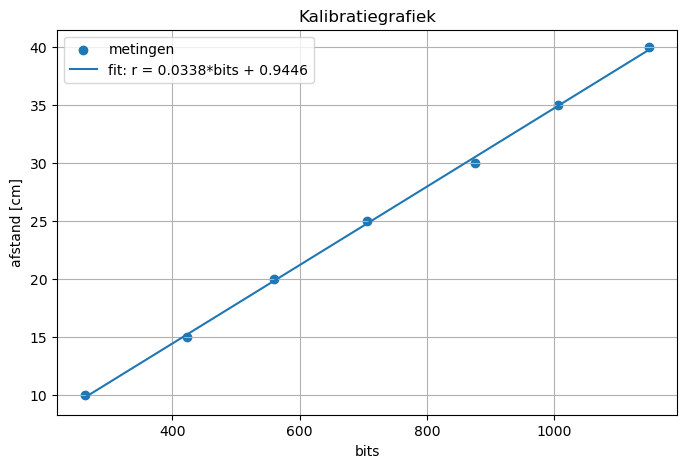

a = 0.033792
b = 0.944603


In [6]:
# x = bits
# y = echte afstand in cm
bits = np.array([263, 423, 560, 706, 876, 1006, 1149], dtype=float)
afstand = np.array([10, 15, 20, 25, 30, 35, 40], dtype=float)

# lineaire fit
a, b = np.polyfit(bits, afstand, 1)

# fit-lijn maken
bits_lijn = np.linspace(min(bits), max(bits), 200)
afstand_lijn = a * bits_lijn + b

# grafiek
plt.figure(figsize=(8,5))
plt.scatter(bits, afstand, label="metingen")
plt.plot(bits_lijn, afstand_lijn, label=f"fit: r = {a:.4f}*bits + {b:.4f}")
plt.xlabel("bits")
plt.ylabel("afstand [cm]")
plt.title("Kalibratiegrafiek")
plt.grid(True)
plt.legend()
plt.show()

print(f"a = {a:.6f}")
print(f"b = {b:.6f}")

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  41.2
1   0  30   0  20  41.5
2   0  10   0  20  49.5
3  40   0  30   0  41.2
4  30   0  20   0  41.5
5  10   0  20   0  51.9
6  10   0   0  10  44.2


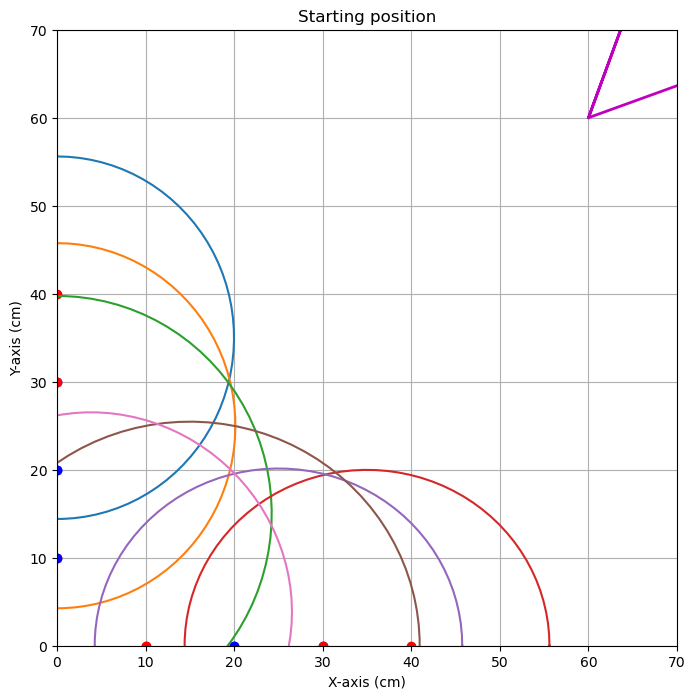


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=105.166


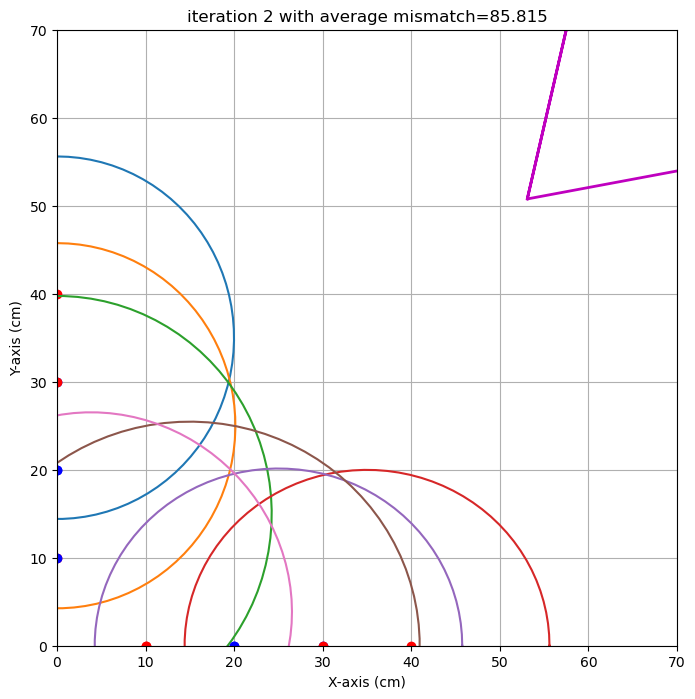

end iteration 2 with average mismatch=85.815


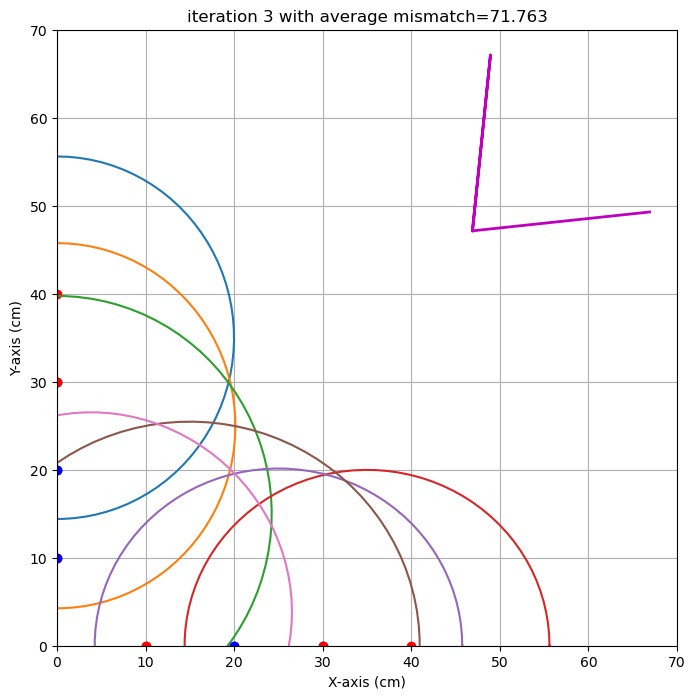

end iteration 3 with average mismatch=71.763


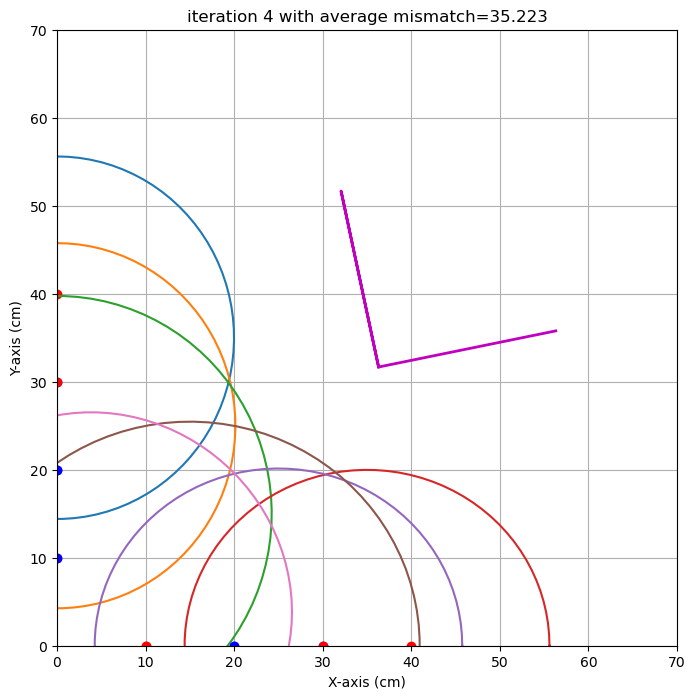

end iteration 4 with average mismatch=35.223


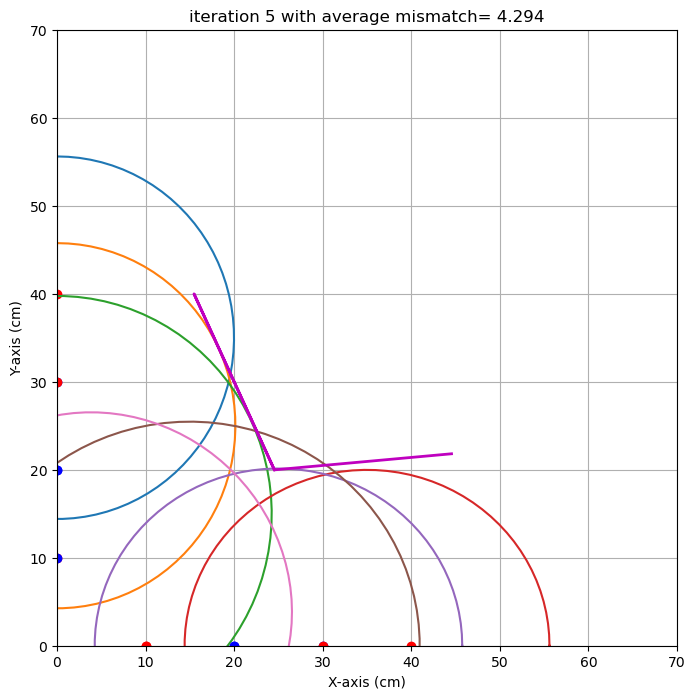

end iteration 5 with average mismatch= 4.294
end iteration 6 with average mismatch= 3.964
end iteration 7 with average mismatch= 3.943
end iteration 8 with average mismatch= 3.862
end iteration 9 with average mismatch= 3.777
end iteration 10 with average mismatch= 3.755
end iteration 11 with average mismatch= 3.741
end iteration 12 with average mismatch= 3.739
end iteration 13 with average mismatch= 3.739
end iteration 14 with average mismatch= 3.739
end iteration 15 with average mismatch= 3.739
end iteration 16 with average mismatch= 3.739
end iteration 17 with average mismatch= 3.739
end iteration 18 with average mismatch= 3.739
end iteration 19 with average mismatch= 3.739
end iteration 20 with average mismatch= 3.739
end iteration 21 with average mismatch= 3.739
end iteration 22 with average mismatch= 3.739
end iteration 23 with average mismatch= 3.739
end iteration 24 with average mismatch= 3.739
end iteration 25 with average mismatch= 3.739
end iteration 26 with average mismatch=

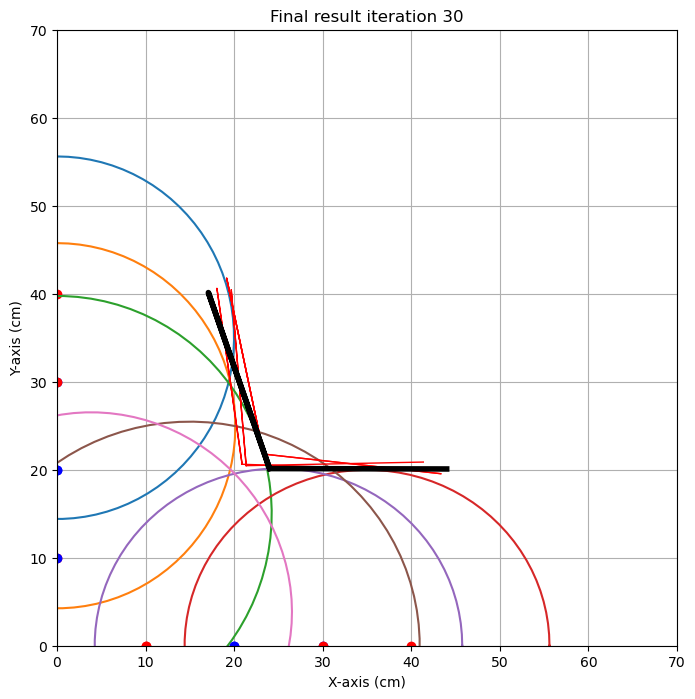

In [9]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30, 41.2],
    [0,30,0,20, 41.5],
    [0,10,0,20, 49.5],
    [40,0,30,0, 41.2],
    [30,0,20,0, 41.5],
    [10,0,20,0, 51.9],
    [10,0,0,10, 44.2]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [8]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 23.6 cm met een standaardafwijking van 3.8 cm 
y0: 20.5 cm met een standaardafwijking van 1.1 cm 
alpha: -1.7 graden met een standaardafwijking van 4.5 graad 
beta: -12.0 graden met een standaardafwijking van 13.5 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Frederik Roerink]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="Algoritme0.jpg" width="400">

Hierbij staat nog niet vermeldt dat de transmitter en receiver omgedraaid worden mits dit wel een realistische output geeft.

## Opdracht 6: Test iteratie 0.

In [17]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 30,  #zelf aanvullen,
           'y0': 30,  #zelf aanvullen,
           'alpha': 10, #zelf aanvullen,
           'beta': 55 #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Frederik' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,0,10,0, 81.6],
    [40,0,30,0, 64.2],
    [50,0,40,0, 40.5],
    [60,0,50,0, 67.7],
    [10,0,0,0, 76.3],
    [10,0,20,0, 62.8],
    [20,0,30,0, 52.3], 
    ]),
      }

## Opdracht 7: Evaluatie.

Frederik
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0   0  10   0  81.6
1  40   0  30   0  64.2
2  50   0  40   0  40.5
3  60   0  50   0  67.7
4  10   0   0   0  76.3
5  10   0  20   0  62.8
6  20   0  30   0  52.3


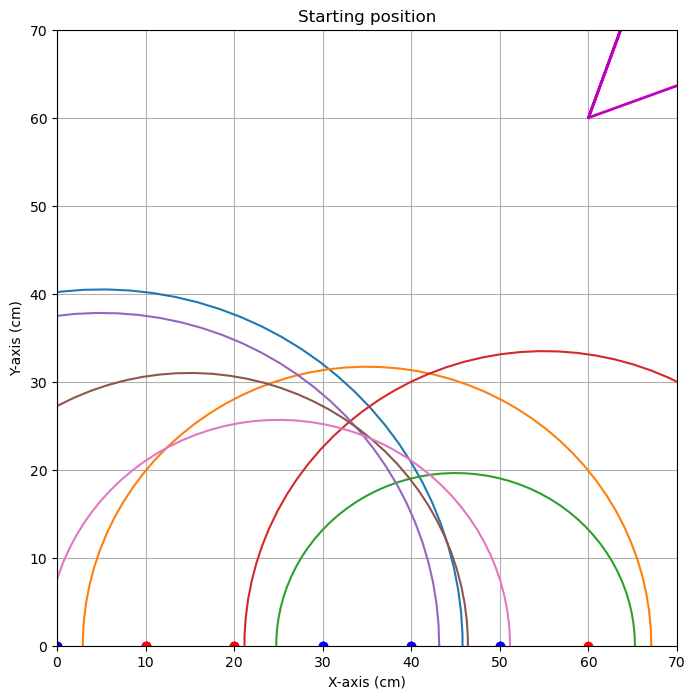


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=86.295


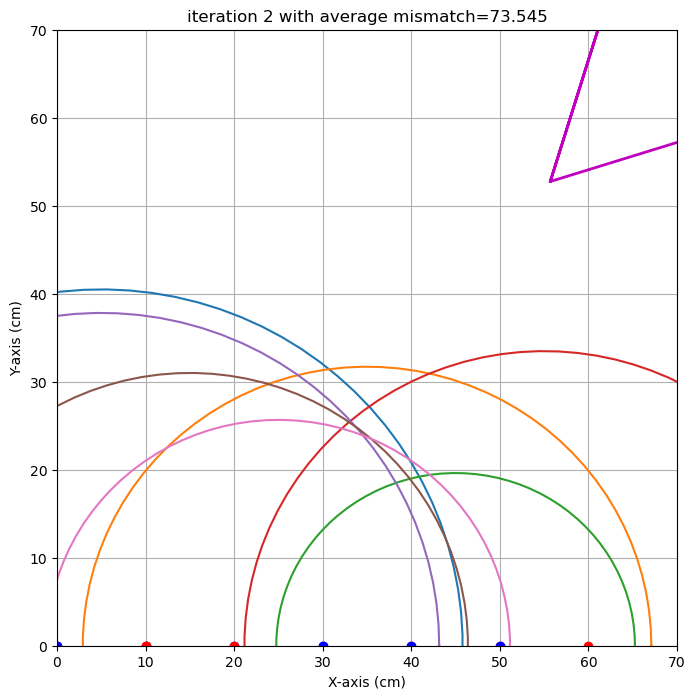

end iteration 2 with average mismatch=73.545


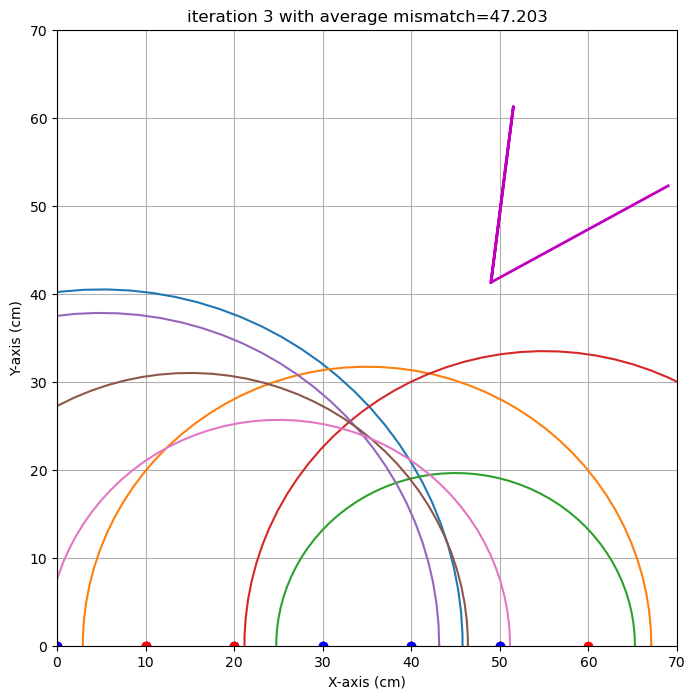

end iteration 3 with average mismatch=47.203


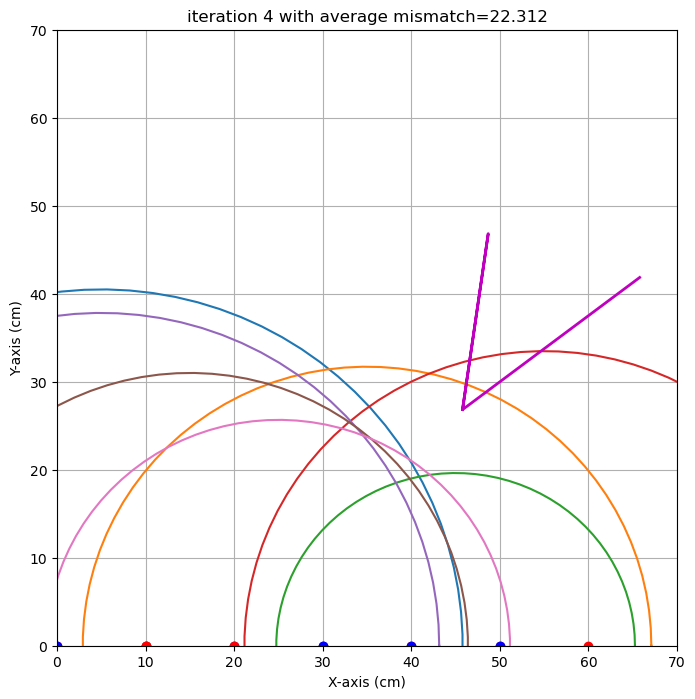

end iteration 4 with average mismatch=22.312


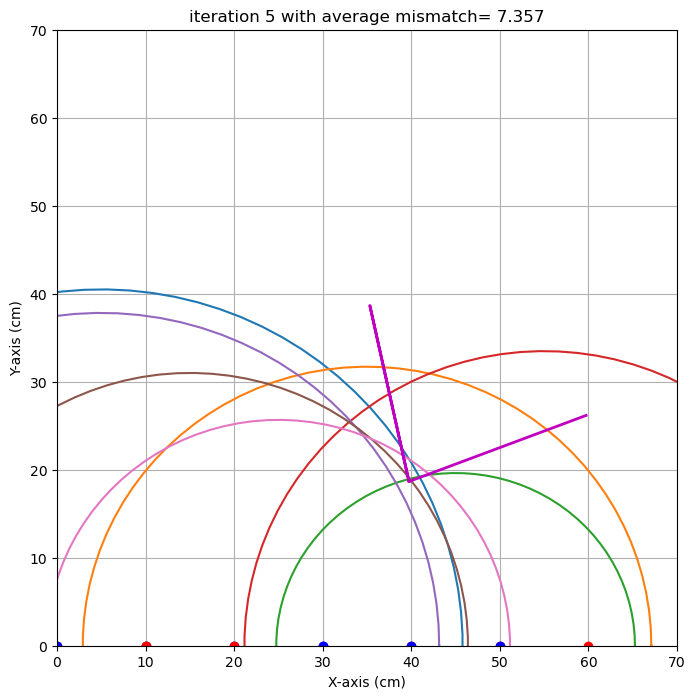

end iteration 5 with average mismatch= 7.357
end iteration 6 with average mismatch= 6.819
end iteration 7 with average mismatch= 6.473
end iteration 8 with average mismatch= 6.352
end iteration 9 with average mismatch= 6.352
end iteration 10 with average mismatch= 5.868
end iteration 11 with average mismatch= 5.810
end iteration 12 with average mismatch= 5.767
end iteration 13 with average mismatch= 5.668
end iteration 14 with average mismatch= 5.668
end iteration 15 with average mismatch= 5.668
end iteration 16 with average mismatch= 5.668
end iteration 17 with average mismatch= 5.668
end iteration 18 with average mismatch= 5.668
end iteration 19 with average mismatch= 5.668
end iteration 20 with average mismatch= 5.668
end iteration 21 with average mismatch= 5.642
end iteration 22 with average mismatch= 5.556
end iteration 23 with average mismatch= 5.556
end iteration 24 with average mismatch= 5.556
end iteration 25 with average mismatch= 5.542
end iteration 26 with average mismatch=

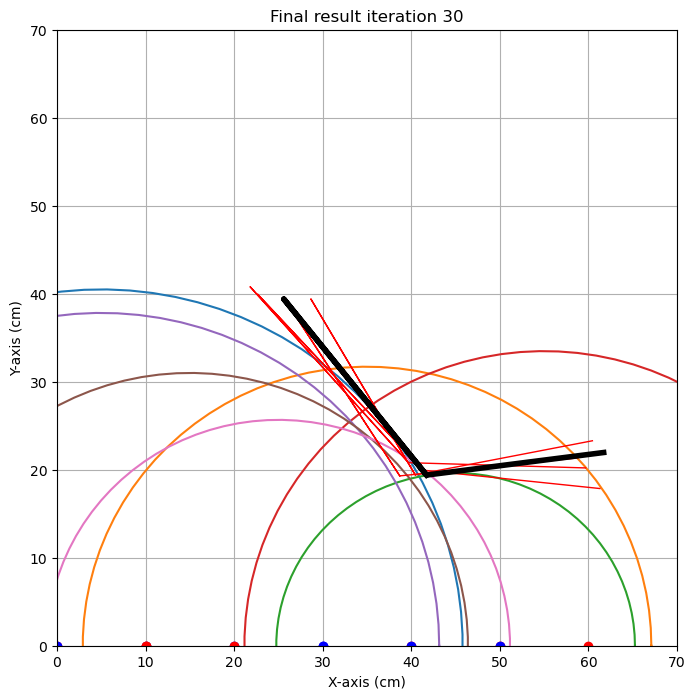

{'alpha': 7.302831330861791, 'alpha_eps': 13.276407956077616, 'beta': -38.85146871740232, 'beta_eps': 8.327989113970485, 'x0': 41.716987190078775, 'x0_eps': 3.021009960168584, 'y0': 19.392215727906844, 'y0_eps': 1.407349837505084}


In [18]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [19]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Frederik 
x0 target is : 30.0. Gevonden waarde: 41.7 cm met een standaardafwijking van 3.0 cm 
y0 target is : 30.0. Gevonden waarde: 19.4 cm met een standaardafwijking van 1.4 cm 
alpha target is : 10.0. Gevonden waarde: 7.3 graden met een standaardafwijking van 13.3 graad 
beta target is : 55.0. Gevonden waarde: -38.9 graden met een standaardafwijking van 8.3 graad 



## Opdracht 8: Iteratie1 18.48
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Algoritme2.jpg)


Het volgende staat niet in het blokschema, maar wordt wel uitgevoerd. Als de transmitter en receiver net geen waarde geven, dus de meting na de laatste succesvolle meting, wordt de receiver iets teruggeschoven tot er wel een realischte waarde gegeven wordt. Deze laatste meting bevordert de accuraatheid.

## Opdracht 9: Iteratie 1+ meeting en test

Locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  21   0  70.6
1  50   0  30   0  46.4
2  60   0  40   0  67.3
3  70   0  50   0  74.2
4  80   0  47   0  83.1
5   0  40   0  20  61.5
6   0  50   0  30  58.7
7   0  60   0  38  66.8


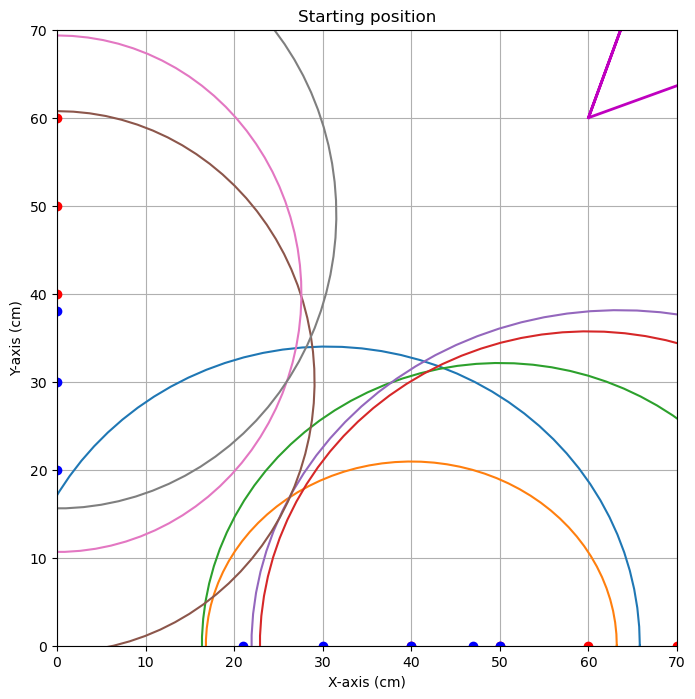


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.469


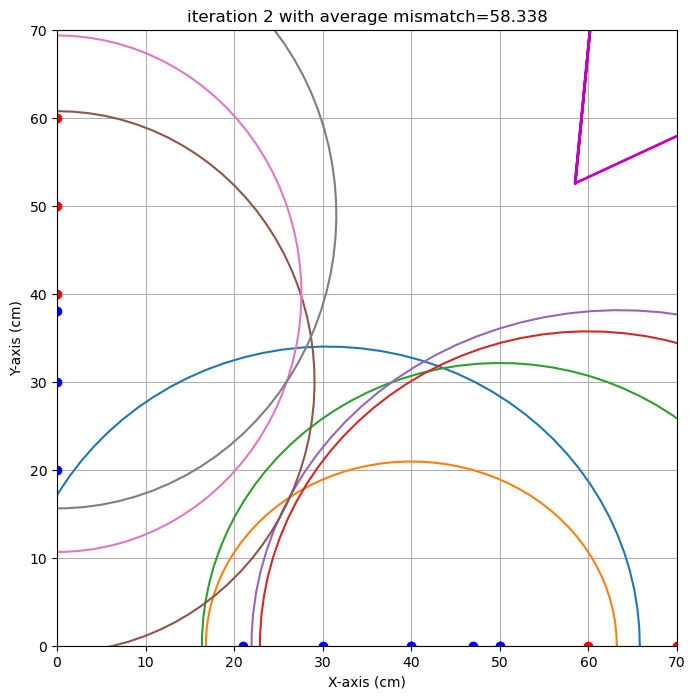

end iteration 2 with average mismatch=58.338


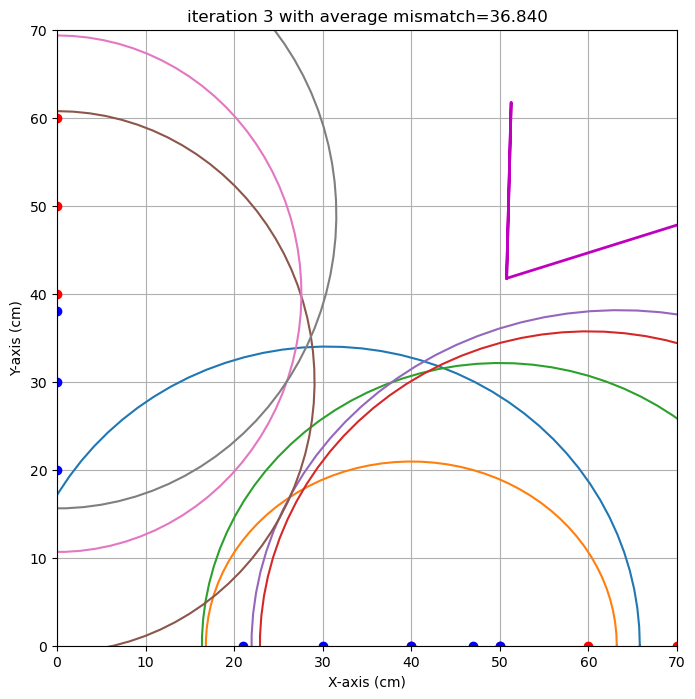

end iteration 3 with average mismatch=36.840


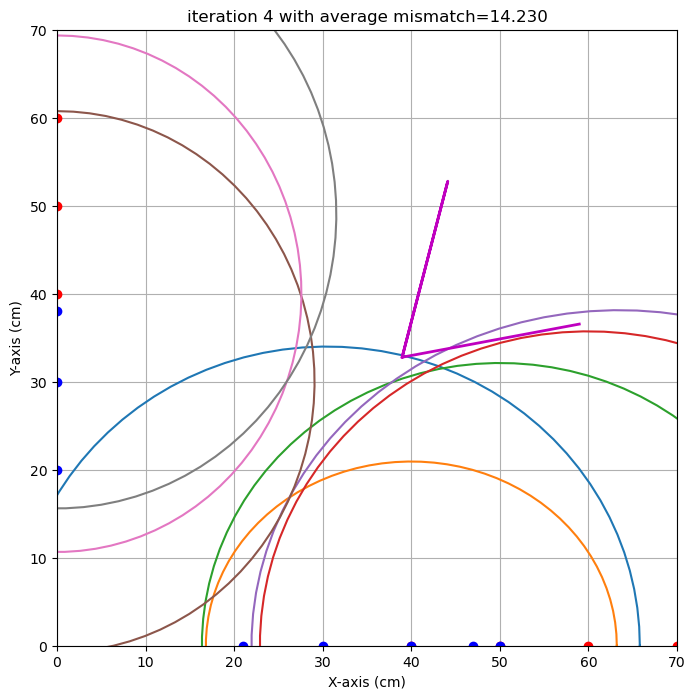

end iteration 4 with average mismatch=14.230


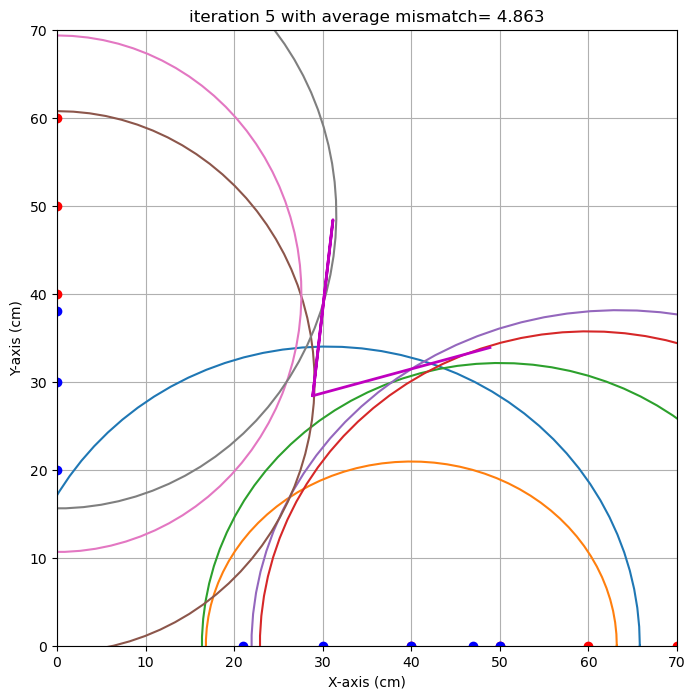

end iteration 5 with average mismatch= 4.863
end iteration 6 with average mismatch= 4.554
end iteration 7 with average mismatch= 4.545
end iteration 8 with average mismatch= 4.451
end iteration 9 with average mismatch= 4.439
end iteration 10 with average mismatch= 4.439
end iteration 11 with average mismatch= 4.439
end iteration 12 with average mismatch= 4.376
end iteration 13 with average mismatch= 4.376
end iteration 14 with average mismatch= 4.376
end iteration 15 with average mismatch= 4.376
end iteration 16 with average mismatch= 4.376
end iteration 17 with average mismatch= 4.376
end iteration 18 with average mismatch= 4.376
end iteration 19 with average mismatch= 4.376
end iteration 20 with average mismatch= 4.376
end iteration 21 with average mismatch= 4.376
end iteration 22 with average mismatch= 4.376
end iteration 23 with average mismatch= 4.376
end iteration 24 with average mismatch= 4.376
end iteration 25 with average mismatch= 4.376
end iteration 26 with average mismatch=

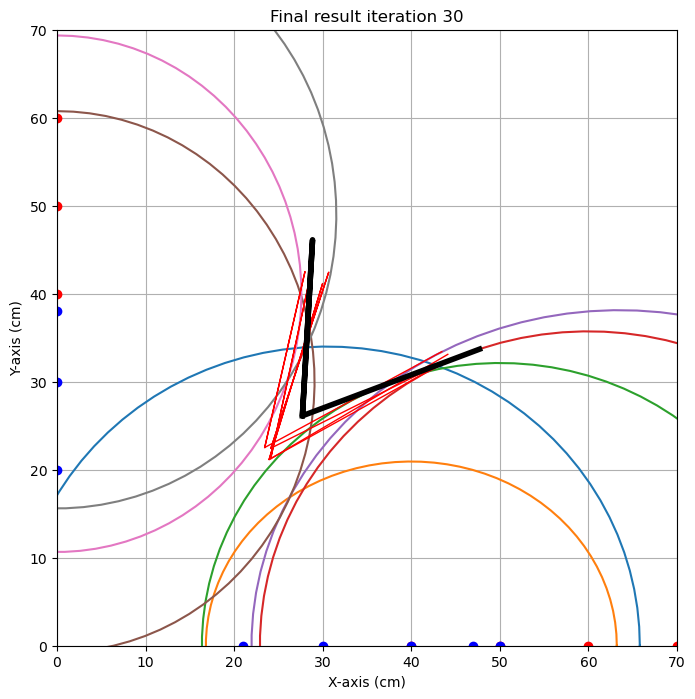

{'alpha': 20.728091639303944, 'alpha_eps': 9.942765351214081, 'beta': 3.2825520642122474, 'beta_eps': 14.789472307857029, 'x0': 27.700949895574126, 'x0_eps': 4.253162930014653, 'y0': 26.129722465155268, 'y0_eps': 4.967754402803173}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0   0  20   0  32.8
1  20   0   0   0  32.3
2  30   0  10   0  29.4
3  40   0  20   0  30.1
4  50   0  20   0  46.2
5   0  30  10   0  30.9
6   0  40   0  20  34.5
7   0  50   0  25  46.8


c:\Users\frede\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


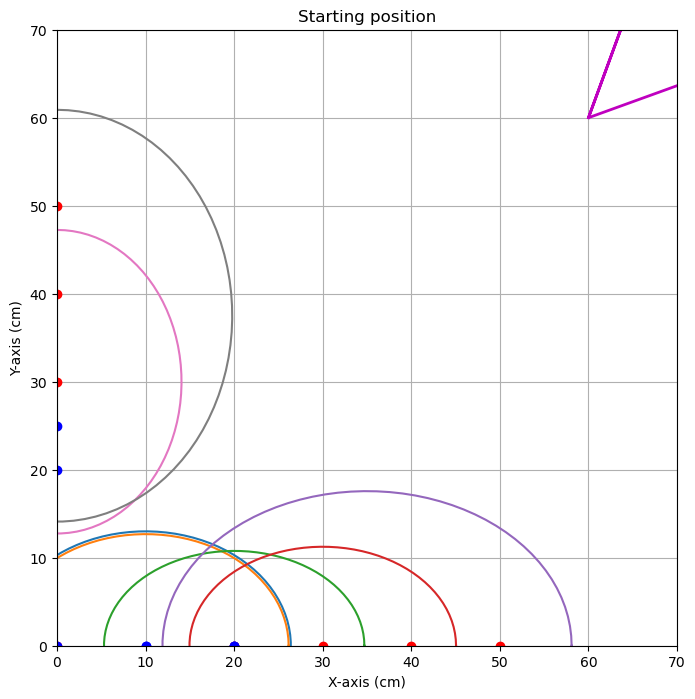


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=114.306


c:\Users\frede\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


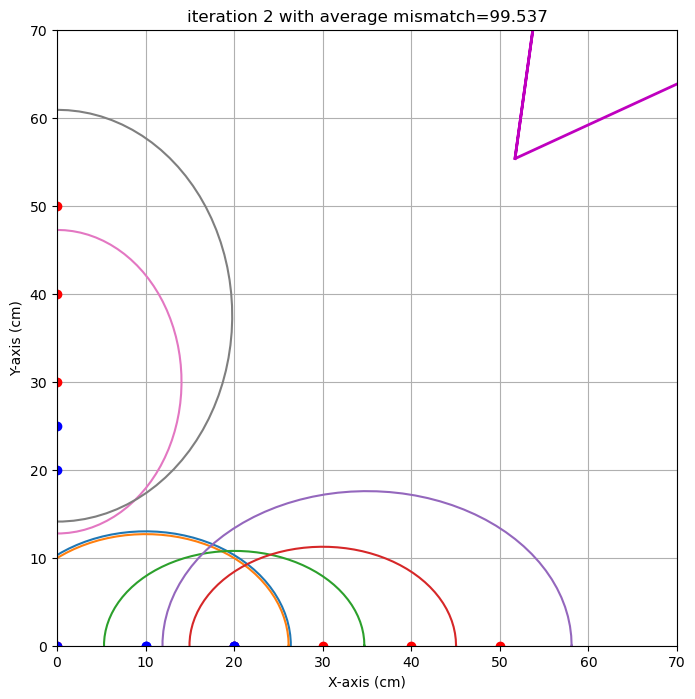

end iteration 2 with average mismatch=99.537


c:\Users\frede\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


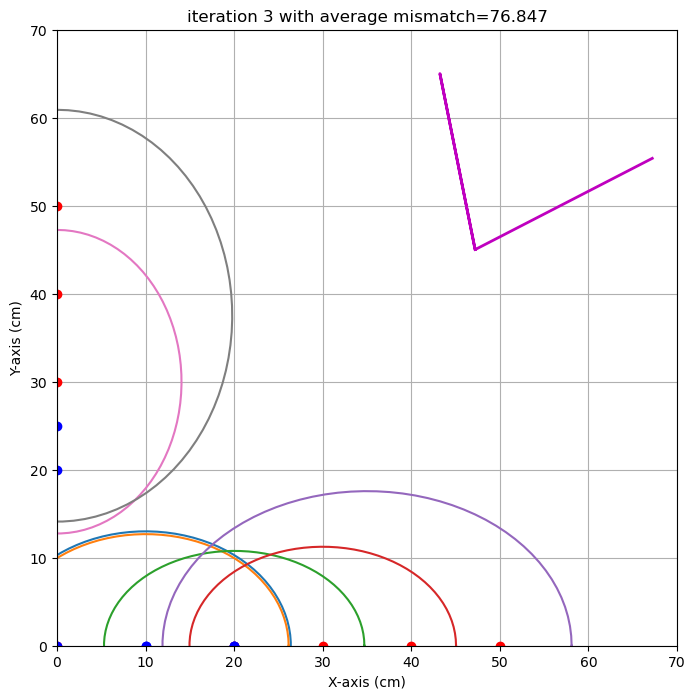

end iteration 3 with average mismatch=76.847


c:\Users\frede\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


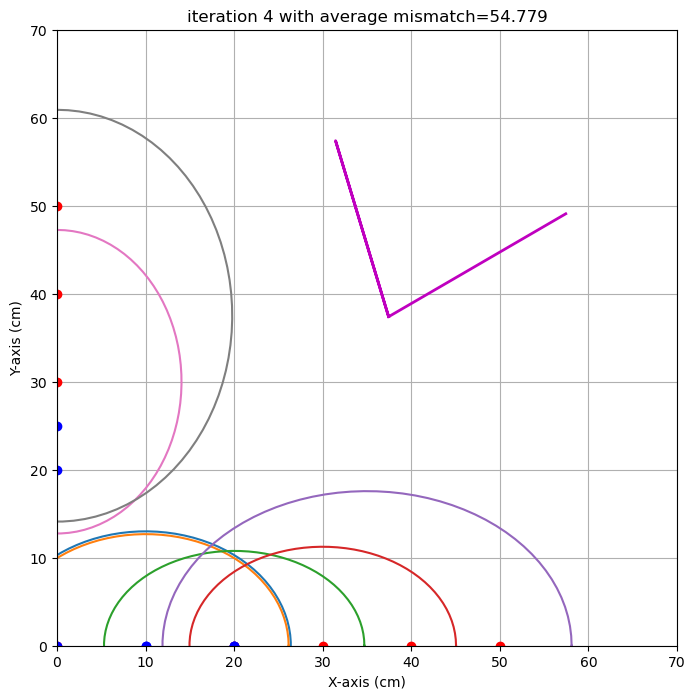

end iteration 4 with average mismatch=54.779


c:\Users\frede\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


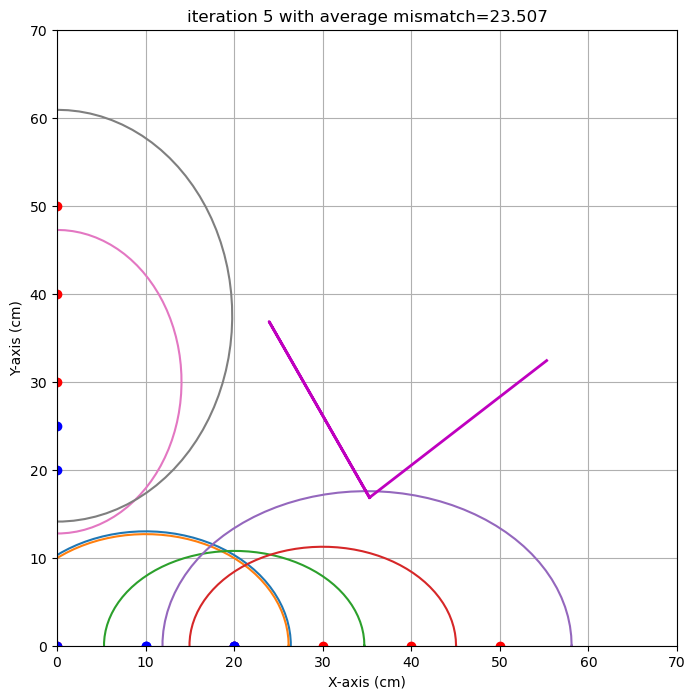

end iteration 5 with average mismatch=23.507


c:\Users\frede\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


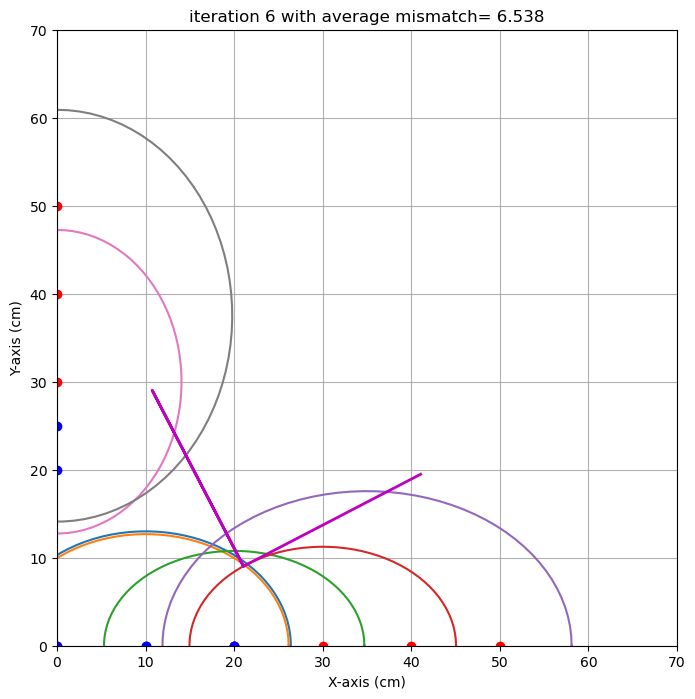

end iteration 6 with average mismatch= 6.538
end iteration 7 with average mismatch= 6.126
end iteration 8 with average mismatch= 6.058
end iteration 9 with average mismatch= 6.043
end iteration 10 with average mismatch= 6.043
end iteration 11 with average mismatch= 5.980
end iteration 12 with average mismatch= 5.980
end iteration 13 with average mismatch= 5.973
end iteration 14 with average mismatch= 5.965
end iteration 15 with average mismatch= 5.952
end iteration 16 with average mismatch= 5.952
end iteration 17 with average mismatch= 5.952
end iteration 18 with average mismatch= 5.952
end iteration 19 with average mismatch= 5.905
end iteration 20 with average mismatch= 5.802
end iteration 21 with average mismatch= 5.574


c:\Users\frede\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


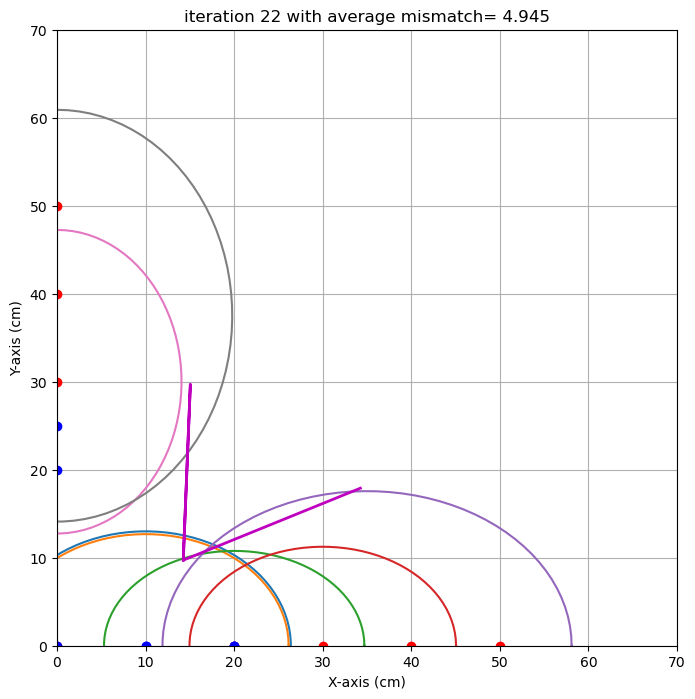

end iteration 22 with average mismatch= 4.945


c:\Users\frede\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


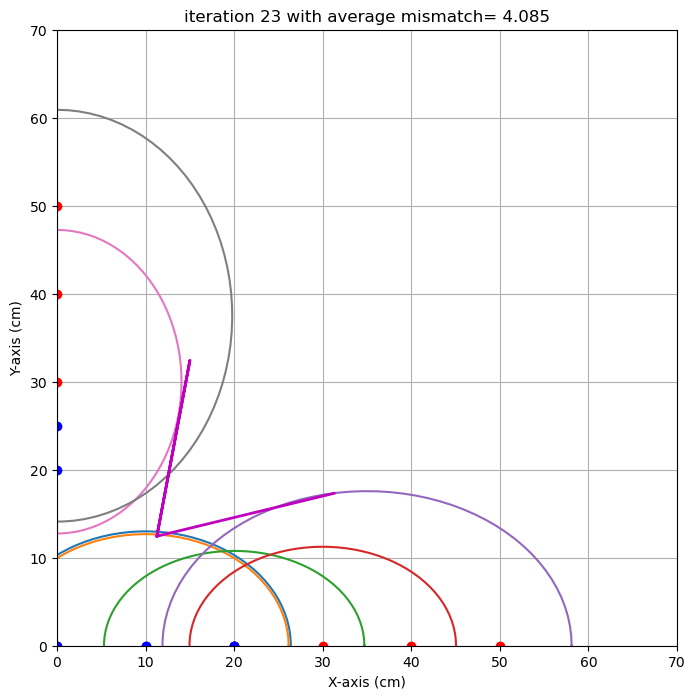

end iteration 23 with average mismatch= 4.085


c:\Users\frede\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


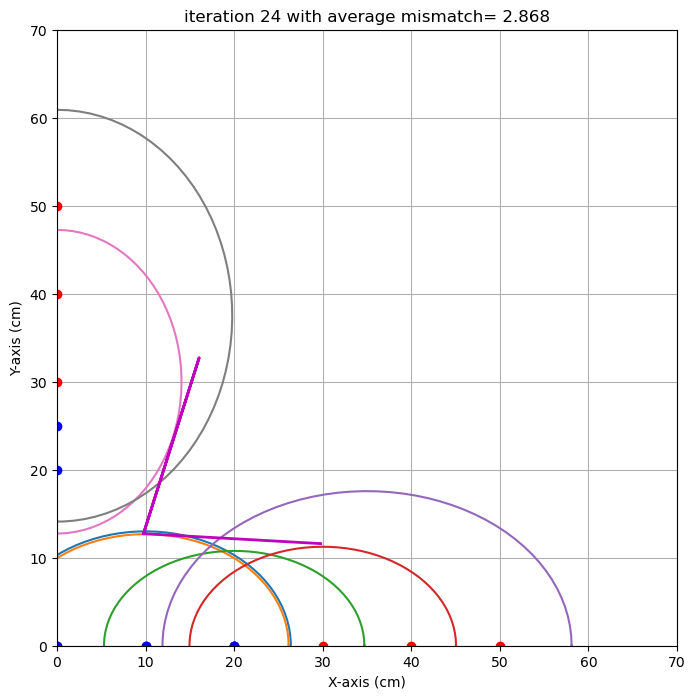

end iteration 24 with average mismatch= 2.868
end iteration 25 with average mismatch= 2.782
end iteration 26 with average mismatch= 2.770
end iteration 27 with average mismatch= 2.751
end iteration 28 with average mismatch= 2.751
end iteration 29 with average mismatch= 2.751
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


c:\Users\frede\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


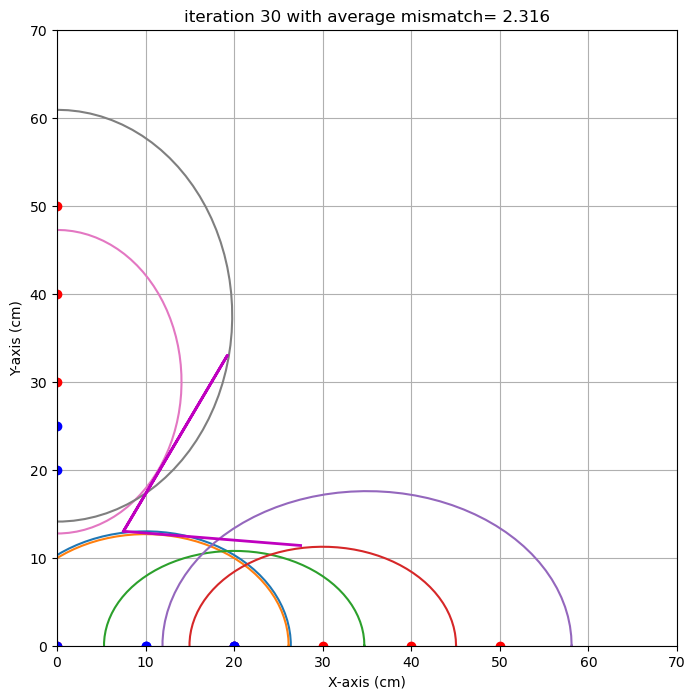

end iteration 30 with average mismatch= 2.316
###############################################################################
end of iteration  30
Best alpha=  -4.62 with uncertainty=   8.18
Best beta =  30.41 with uncertainty=  12.59
Best x0   =   7.50 with uncertainty=   1.40
Best y0   =  13.01 with uncertainty=   1.34
###############################################################################


c:\Users\frede\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


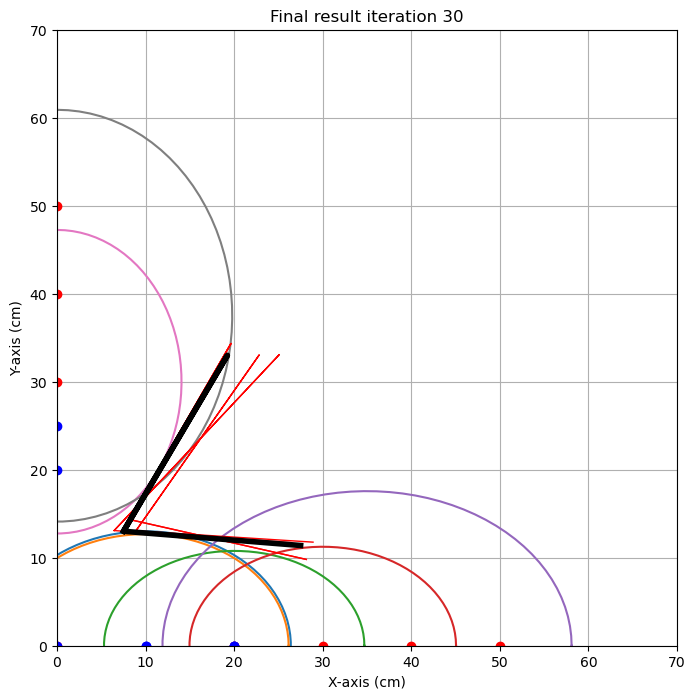

{'alpha': -4.62271275563739, 'alpha_eps': 8.177074125936116, 'beta': 30.40754325524599, 'beta_eps': 12.59245674475401, 'x0': 7.500727556296733, 'x0_eps': 1.4027501567246485, 'y0': 13.006985675871723, 'y0_eps': 1.3425568006872002}
Locatie 1 
x0 target is : 30.0. Gevonden waarde: 27.7 cm met een standaardafwijking van 4.3 cm 
y0 target is : 30.0. Gevonden waarde: 26.1 cm met een standaardafwijking van 5.0 cm 
alpha target is : 10.0. Gevonden waarde: 20.7 graden met een standaardafwijking van 9.9 graad 
beta target is : 10.0. Gevonden waarde: 3.3 graden met een standaardafwijking van 14.8 graad 

locatie 2 
x0 target is : 10.0. Gevonden waarde: 7.5 cm met een standaardafwijking van 1.4 cm 
y0 target is : 10.0. Gevonden waarde: 13.0 cm met een standaardafwijking van 1.3 cm 
alpha target is : 2.0. Gevonden waarde: -4.6 graden met een standaardafwijking van 8.2 graad 
beta target is : 12.0. Gevonden waarde: 30.4 graden met een standaardafwijking van 12.6 graad 



In [30]:
# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {
    'Locatie 1': {
        'x0': 30,
        'y0': 30,
        'alpha': 10,
        'beta': 10
    },
    'locatie 2': {
        'x0': 10,
        'y0': 10,
        'alpha': 2,
        'beta': 12
    }
}

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'Locatie 1' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,21,0, 70.6],
    [50,0,30,0, 46.4],
    [60,0,40,0, 67.3],
    [70,0,50,0, 74.2],
    [80,0,47,0, 83.1],
    [0,40,0,20, 61.5],
    [0,50,0,30, 58.7],
    [0,60,0,38, 66.8],
    ]),
    'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,0,20,0, 32.8],
    [20,0,0,0, 32.3],
    [30,0,10,0, 29.4],
    [40,0,20,0, 30.1],
    [50,0,20,0, 46.2],
    [0,30,10,0, 30.9],
    [0,40,0,20, 34.5],
    [0,50,0,25, 46.8],
    ]),
}
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
        x0Target=targets[locatie]['x0'],
        x0=resultaat[locatie]['x0'],
        x0_eps=resultaat[locatie]['x0_eps'],
        y0Target=targets[locatie]['y0'],
        y0=resultaat[locatie]['y0'],
        y0_eps=resultaat[locatie]['y0_eps'],
        alphaTarget=targets[locatie]['alpha'],
        alpha=resultaat[locatie]['alpha'],
        alpha_eps=resultaat[locatie]['alpha_eps'],
        betaTarget=targets[locatie]['beta'],
        beta=resultaat[locatie]['beta'],
        beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

Omdat ik de opdracht heb ingehaald, kan ik geen locatie laten aanwijzen door een TA. Ik hoop daarmee dat de twee locaties uit de vorige opdracht genoeg zijn.

## Verklaring afwijking

De gevonden positie door het algoritme wijkt af van de werkelijke positie van het scherm. Een verklaring hiervoor is een fout in de kalibratie. Bij de eerste sanity check, waarbij het scherm op (20,20) werd geplaatst en zowel $\alpha$ als $\beta$ op 0 werden gezet, vond de code toch een $\beta$-waarde van -12 graden. Dit betekent dat de kalibratie niet juist/nauwkeurig genoeg is gedaan. Hierdoor komt er een verkeerde helling en b-waarde uit de kalibratie-grafiek. Deze waardes worden later ook in het algoritme gebruikt om de positie van het scherm te vinden. Hierdoor wijkt de gevonden positie af van de werkelijke positie. 

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](Algoritme0.jpg "Title")

Figuur: ![Alt](Algoritme2.jpg "Title")

De gevonden positie door het algoritme wijkt af van de werkelijke positie van het scherm. Een verklaring hiervoor is een fout in de kalibratie. Bij de eerste sanity check, waarbij het scherm op (20,20) werd geplaatst en zowel $\alpha$ als $\beta$ op 0 werden gezet, vond de code toch een $\beta$-waarde van -12 graden. Dit betekent dat de kalibratie niet juist/nauwkeurig genoeg is gedaan. Hierdoor komt er een verkeerde helling en b-waarde uit de kalibratie-grafiek. Deze waardes worden later ook in het algoritme gebruikt om de positie van het scherm te vinden. Hierdoor wijkt de gevonden positie af van de werkelijke positie. 